## **Long-term Myelin Water Imaging of Multiple Sclerosis Lesions Reveals Substantial Inter-individual Variability in Myelin Recovery** 

This script summarize the paper results of PyAFIL approach using Linear mixed model results, which were analyzed separately. With the LMM MWF slopes for short-term and long-term treatment phase were estimated for every tracked lesion, and compared to NAWM ROI slopes. 

In [1]:
%matplotlib inline
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from os.path import abspath, dirname, join, isfile, exists
import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
sns.set_style("whitegrid")
from scipy import stats
from matplotlib.pyplot import figure, vlines, axvspan
from scipy.stats import ttest_rel, wilcoxon, mannwhitneyu, spearmanr
import starbars 

In [2]:
from pathlib import Path
projectdir = Path.cwd()

PosixPath('/data/jupyterhub/work/koehlerca/AFIL_paper')

## Contents

1. [Group comparison MWF slopes in new T2L vs persistent (Figure1)](#Figure1)
2. [Individual MWF lesion development (Figure2_values)](#Figure2_values)
3. [Heatmaps (Heatmap_Figure_4_and_Figure_5)](#Heatmap_Figure_4_and_Figure_5) 
4. [Inter patient comparison (Figure_6_Inter_Patient_Comparison)](#Figure_6_Inter_Patient_Comparison)
5. [Clinical development (Tab1)](#patient_characteristics)

## load-dataset PyAFILlesion tracking results

In [3]:
from os import listdir
from os.path import isfile, join
path= join(projectdir,'derivatives','paper_results','AFIL_results.xlsx')
df=pd.read_excel(path)
df=df.dropna(subset=['glbl']) 
df['ROI']='T2L'
df=df.query('volume>3 and map=="mwf"')
df#.columns

,glbl,volume,map,mean,std,median,1_quantile,3_quantile,min,max,new,vanished,session,month,subject_id,ilbl,child_ilbl,parent_ilbl,corresp_glbl,ROI
0,1.0,4,mwf,0.222411,0.009641,0.222792,0.213432,0.231771,0.211582,0.232479,NaN,NaN,0m,0,DEV001,NaN,NaN,NaN,NaN,T2L
4,2.0,90,mwf,0.075461,0.029402,0.082555,0.061555,0.096406,0.007491,0.129306,NaN,NaN,0m,0,DEV001,NaN,NaN,NaN,NaN,T2L
8,3.0,73,mwf,0.106487,0.040428,0.108317,0.076156,0.130976,0.033139,0.175881,NaN,NaN,0m,0,DEV001,NaN,NaN,NaN,NaN,T2L
12,4.0,17211,mwf,0.118899,0.058421,0.118591,0.073652,0.162442,0.001015,0.257025,NaN,NaN,0m,0,DEV001,NaN,NaN,NaN,NaN,T2L
16,5.0,87,mwf,0.162213,0.023653,0.169567,0.146983,0.178184,0.102704,0.201924,NaN,NaN,0m,0,DEV001,NaN,NaN,NaN,NaN,T2L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93385,47.0,9,mwf,0.189683,0.009699,0.187420,0.179515,0.198604,0.176014,0.202979,NaN,NaN,71m,71,DEV034,NaN,NaN,NaN,NaN,T2L
93389,48.0,11,mwf,0.167483,0.007972,0.167679,0.162951,0.173479,0.153472,0.179077,NaN,NaN,71m,71,DEV034,NaN,NaN,NaN,NaN,T2L
93397,50.0,9,mwf,0.105140,0.028669,0.114937,0.081163,0.128927,0.056991,0.142806,NaN,NaN,71m,71,DEV034,NaN,NaN,NaN,NaN,T2L
93405,52.0,8,mwf,0.252494,0.002063,0.252510,0.251362,0.253892,0.248617,0.255363,NaN,NaN,71m,71,DEV034,NaN,NaN,NaN,NaN,T2L


In [4]:
# load NAWM ROIs from patients MWF
path_NAWM= join(projectdir,'derivatives','paper_results','dummy_lesions.csv')
df_NAWM=pd.read_csv(path_NAWM)
#df_NAWM=df.dropna(subset=['glbl']) 
df_NAWM['ROI']='NAWM'
df.rename(columns={"volume": "voxel_count"})
df_NAWM

,mean,std,median,1_quantile,3_quantile,min,max,map,volume,subject_id,session,glbl,month,ROI
0,0.258095,0.002194,0.258896,0.256476,0.259905,0.252768,0.261030,mwf,64,DEV001,0m,1,0,NAWM
1,0.255872,0.004203,0.257427,0.252353,0.259142,0.245111,0.261333,mwf,49,DEV001,0m,2,0,NAWM
2,0.261494,0.001712,0.262020,0.260211,0.262827,0.258917,0.263709,mwf,9,DEV001,0m,3,0,NAWM
3,0.258320,0.002012,0.258894,0.257514,0.259857,0.252095,0.261478,mwf,64,DEV001,1m,1,1,NAWM
4,0.257004,0.003111,0.257760,0.255636,0.259479,0.246474,0.261182,mwf,49,DEV001,1m,2,1,NAWM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898,0.227777,0.008733,0.228762,0.222952,0.235255,0.207789,0.241722,mwf,49,DEV034,63m,2,63,NAWM
899,0.260949,0.000720,0.261024,0.260898,0.261580,0.259268,0.261684,mwf,9,DEV034,63m,3,63,NAWM
900,0.232860,0.005918,0.230827,0.227988,0.237226,0.225126,0.248441,mwf,64,DEV034,71m,1,71,NAWM
901,0.235872,0.011374,0.238044,0.229844,0.245307,0.211580,0.254910,mwf,49,DEV034,71m,2,71,NAWM


In [5]:
# load MWF of WM ROIs from controls
path_NAWM_hc= join(projectdir,'derivatives','paper_results','MWF_rois_hc.csv')
df_NAWM_hc=pd.read_csv(path_NAWM_hc)
#df_NAWM=df.dropna(subset=['glbl']) 
df_NAWM_hc.rename(columns={"volume": "voxel_count"})
df_NAWM_hc['month']=0
df_NAWM_hc

,glbl,mean,median,std,volume,subject_id,ROI,month
0,1.0,0.256372,0.257467,0.004185,25.0,N003,WM_controls,0
1,2.0,0.259534,0.259896,0.002239,25.0,N003,WM_controls,0
2,3.0,0.260371,0.260637,0.001408,36.0,N003,WM_controls,0
3,4.0,0.261327,0.261456,0.001822,36.0,N003,WM_controls,0
4,5.0,0.260502,0.260623,0.001711,49.0,N003,WM_controls,0
...,...,...,...,...,...,...,...,...
139,2.0,0.259534,0.259896,0.002239,25.0,N054,WM_controls,0
140,3.0,0.260371,0.260637,0.001408,36.0,N054,WM_controls,0
141,4.0,0.261327,0.261456,0.001822,36.0,N054,WM_controls,0
142,5.0,0.260502,0.260623,0.001711,49.0,N054,WM_controls,0


In [6]:
# load demographic data from controls
demographic_controls=  pd.read_excel(join(projectdir,'derivatives','paper_results','controls_demographics.xlsx'))

In [7]:
# merge df lesion and df NAWM and df_NAWM_hc
merge=df.merge(df_NAWM, how='outer')
merge=merge.merge(df_NAWM_hc, how='outer')

## 3.1 Baseline MWF level comparison

In [8]:
# Estimate group differences in baseline MWF 
data_0m= merge.query("month == 0")
WM_controls= data_0m.query('ROI=="WM_controls"')['median'].to_list()
NAWM_patients= data_0m.query('ROI=="NAWM"')['median'].to_list()
T2L= data_0m.query('ROI=="T2L"')['median'].to_list()
from scipy.stats import ttest_rel, wilcoxon, mannwhitneyu, spearmanr
res= mannwhitneyu(WM_controls, NAWM_patients, nan_policy='omit' )
print('Does statistical difference exist between MWF of WM ROIs and NAWM ROIs, p= ', round(res[1],4))
res2= mannwhitneyu(WM_controls, T2L, nan_policy='omit' )
print('Does statistical difference exist between MWF of WM ROIs and T2L, p=', res2[1])
res3= mannwhitneyu(NAWM_patients, T2L, nan_policy='omit' )
print('Does statistical difference exist between MWF of NAWM ROIs and T2L, p=', res3[1])

print('WM_controls: mean,',round(np.mean(WM_controls),3), 'sd',  round(np.std(WM_controls),3))
print('NAWM_patients: ROIs mean,', round(np.mean(NAWM_patients),3), 'sd',  round(np.std(NAWM_patients),3))
print('T2L: mean,', round(np.mean(T2L),3), 'sd',  round(np.std(T2L),3))

Does statistical difference exist between MWF of WM ROIs and NAWM ROIs, p=  0.1482
Does statistical difference exist between MWF of WM ROIs and T2L, p= 4.50065062505798e-80
Does statistical difference exist between MWF of NAWM ROIs and T2L, p= 1.2669403957022954e-43
WM_controls: mean, 0.26 sd 0.001
NAWM_patients: ROIs mean, 0.259 sd 0.004
T2L: mean, 0.175 sd 0.045


In [9]:
# load patient demographic an clinical development
clinical_df=pd.read_excel(join(projectdir,'derivatives','paper_results','dev_clinical.xlsx'))
demography_df=pd.read_excel(join(projectdir,'derivatives','paper_results','dev_demographics.xlsx'))


## MWF slopes from LMM

In [10]:
## NAWM ROI slope thresholds from model (agerage slope for dummy lesions+/- 5*standard error)

In [11]:
NAWM_slope_threshold_low= -0.0022
NAWM_slope_threshold_upper=0.0022

print('NAWM_slope_threshold_low:' , round(NAWM_slope_threshold_low, 4))
print('NAWM_slope_threshold_upper:' , round(NAWM_slope_threshold_upper, 4))

NAWM_slope_threshold_low: -0.0022
NAWM_slope_threshold_upper: 0.0022


In [12]:
# load intercept and slopes from LMM lesion tracking results
path= join(projectdir,'derivatives','paper_results')
# LMM slopes update no percentage anymore and intercept is now per year not month like in prior versions
LMM_slopes=pd.read_csv(join(path,'pred_intrcpt_slp_2025-12-02.csv'))
LMM_slopes
#split text of column_name to get glbl 
LMM_slopes[['First_Name','lesion_type', 'glbl']] = LMM_slopes.lesion_id.str.split("_", expand = True)
LMM_slopes['glbl']=LMM_slopes['glbl'].astype('int')

LMM_slopes.loc[:, 'lesion_type']= LMM_slopes['lesionType'].replace({'real': 'T2L', 'dummy': 'NAWM_ROI'})
LMM_slopes['month']= LMM_slopes['monthMin']

# no adjustment after update
LMM_slopes_adjusted=LMM_slopes[['subject_id', 'glbl','lesion_type', 'month', 'new', 'intrcpt_initial', 'slope_initial', 'slope_late' ]]
LMM_slopes_adjusted.loc[:,'intrcpt_initial']= LMM_slopes_adjusted['intrcpt_initial']
LMM_slopes_adjusted.loc[:, 'slope_initial'] = LMM_slopes_adjusted['slope_initial']
LMM_slopes_adjusted.loc[:, 'slope_late']= LMM_slopes_adjusted['slope_late']

In [13]:
# assign a category assoziated from NAWM ROI MWF slopes
def slope_severity(x):
    if pd.isna(x):
        return np.nan
    elif x>=0.002:
        cat='increase'
    elif (x>(-0.0022) and x<(0.002)):
        cat='stable'
    else :
        cat='decrease'
    return cat

In [50]:
# apply slope category to the dataframe
LMM_slopes_adjusted.loc[:,'slope_cat_initial']=LMM_slopes_adjusted['slope_initial'].apply(slope_severity)
LMM_slopes_adjusted.loc[:,'slope_cat_late']=LMM_slopes_adjusted['slope_late'].apply(slope_severity)

## Figure1

2.0 0.03
0.003399641271512196
0.0014775304995002937


/tmp/ipykernel_2024189/1840762565.py:10: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  ax=sns.stripplot(data=data, hue='new', x='new', y='slope_initial',  palette=palette, ax=ax, size= 2, color='white', linewidth=0.5, edgecolor='gray', zorder=2, jitter=0.12)


<Figure size 350x400 with 0 Axes>

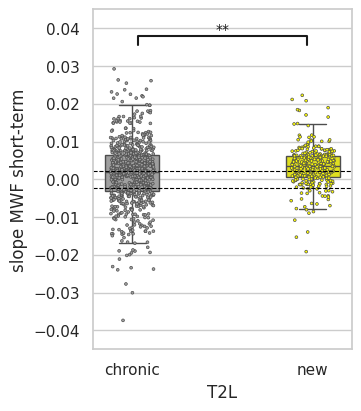

In [15]:
# display MWF slope differences between baseline existing lesions in initial phase and new lesions
sns.set_theme(style='whitegrid')
plt.figure(figsize=(3.5,4))
data= LMM_slopes_adjusted[(LMM_slopes_adjusted['lesion_type']=='T2L')] 


palette=["#9f9f9fff", "yellow"]
fig, ax = plt.subplots(figsize=(3.5, 4),  constrained_layout=True)
#ax.margins(x=0.02)
ax=sns.stripplot(data=data, hue='new', x='new', y='slope_initial',  palette=palette, ax=ax, size= 2, color='white', linewidth=0.5, edgecolor='gray', zorder=2, jitter=0.12)
ax=sns.boxplot(data=data, hue='new', x='new', y='slope_initial', palette=palette,ax=ax, showfliers = False, width=0.3, zorder=1)
plt.ylabel('slope MWF short-term',  fontsize='12', horizontalalignment='center') 
labels = ['chronic', 'new']
plt.xlabel('T2L')

annotations = [ (0, 1, 0.0012)]
starbars.draw_annotation(annotations)

ax.axhline(
    y= NAWM_slope_threshold_low,
    linestyle='--',
    linewidth=0.8,
    label='NAWM_slope_threshold',
    color='black'
)

ax.axhline(
    y= NAWM_slope_threshold_upper,
    linestyle='--',
    linewidth=0.8,
    label='NAWM_slope_threshold',
    color='black'
)

x=[0,1]
plt.xticks(x,labels)

ax.set_ylim(-0.045, 0.045)
#sns.plt.xlim(0,)

print(np.mean(data[data['new']=='new']['slope_initial']))
print(np.mean(data[data['new']=='_ref']['slope_initial']))

plt.show()

/tmp/ipykernel_2024189/2340765725.py:8: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=data,hue='new', x='new', y='slope_late', palette=palette, ax=ax, size= 2, color='white', linewidth=0.3, edgecolor='gray', zorder=2, jitter=0.12)


2.0 0.03
0.003399641271512196
0.0014775304995002937


<Figure size 350x400 with 0 Axes>

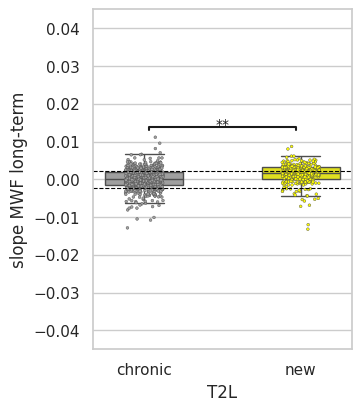

In [16]:
# display MWF slope differences between baseline existing lesions in initial phase and new lesions
sns.set_theme(style='whitegrid')
plt.figure(figsize=(3.5,4))
data= LMM_slopes_adjusted[(LMM_slopes_adjusted['lesion_type']=='T2L')] 

palette=["#9f9f9fff", "yellow"]
fig, ax = plt.subplots(figsize=(3.5, 4),  constrained_layout=True)
sns.stripplot(data=data,hue='new', x='new', y='slope_late', palette=palette, ax=ax, size= 2, color='white', linewidth=0.3, edgecolor='gray', zorder=2, jitter=0.12)
sns.boxplot(data=data, hue='new', x='new', y='slope_late', palette=palette,ax=ax, showfliers = False, width=0.5, zorder=1)
plt.ylabel('slope MWF long-term',  fontsize='12', horizontalalignment='center') 
labels = ['chronic', 'new']
plt.xlabel('T2L')

annotations = [ (0, 1, 0.0012)]
starbars.draw_annotation(annotations)

ax.axhline(
    y= NAWM_slope_threshold_low,
    linestyle='--',
    linewidth=0.8,
    label='NAWM_slope_threshold',
    color='black'
)

ax.axhline(
    y= NAWM_slope_threshold_upper,
    linestyle='--',
    linewidth=0.8,
    label='NAWM_slope_threshold',
    color='black'
)

x=[0,1]
plt.xticks(x,labels)
ax.set_ylim(-0.045, 0.045)
print(np.mean(data[data['new']=='new']['slope_initial']))
print(np.mean(data[data['new']=='_ref']['slope_initial']))

plt.show()

In [17]:
# merge MWF lesion characteristics with corresponding LMM slopes
MWF_slopes= df.merge(LMM_slopes_adjusted, how='left', left_on=['subject_id', 'glbl', 'month','new'], right_on=['subject_id','glbl', 'month', 'new'])

## Figure2_values

In [18]:
# get values of individual T2L developments
df.query("subject_id == 'DEV026' and `glbl` == 1 and map== 'mwf'") 

,glbl,volume,map,mean,std,median,1_quantile,3_quantile,min,max,new,vanished,session,month,subject_id,ilbl,child_ilbl,parent_ilbl,corresp_glbl,ROI
77541,1.0,80,mwf,0.164637,0.040250,0.163590,0.134927,0.192528,0.091794,0.243132,NaN,NaN,0m,0,DEV026,NaN,NaN,NaN,NaN,T2L
77631,1.0,97,mwf,0.186910,0.029482,0.191525,0.171301,0.209071,0.114206,0.240671,NaN,NaN,1m,1,DEV026,NaN,NaN,NaN,NaN,T2L
77730,1.0,68,mwf,0.165043,0.033057,0.163086,0.137954,0.188328,0.098330,0.222363,NaN,NaN,2m,2,DEV026,NaN,NaN,NaN,NaN,T2L
77820,1.0,58,mwf,0.158076,0.031750,0.158565,0.134482,0.184050,0.091899,0.211069,NaN,NaN,3m,3,DEV026,NaN,NaN,NaN,NaN,T2L
77910,1.0,58,mwf,0.150026,0.039176,0.152123,0.117341,0.180007,0.074284,0.225390,NaN,NaN,9m,9,DEV026,NaN,NaN,NaN,NaN,T2L
78000,1.0,58,mwf,0.132125,0.030953,0.132452,0.106418,0.151340,0.078311,0.191984,NaN,NaN,15m,15,DEV026,NaN,NaN,NaN,NaN,T2L
78087,1.0,58,mwf,0.142487,0.039182,0.139828,0.117187,0.164754,0.069326,0.228713,NaN,NaN,21m,21,DEV026,NaN,NaN,NaN,NaN,T2L
78177,1.0,62,mwf,0.138532,0.049867,0.139597,0.104222,0.174337,0.038189,0.241790,NaN,NaN,27m,27,DEV026,NaN,NaN,NaN,NaN,T2L
78258,1.0,62,mwf,0.108236,0.038962,0.108313,0.079964,0.140112,0.035910,0.203315,NaN,NaN,39m,39,DEV026,NaN,NaN,NaN,NaN,T2L
78342,1.0,53,mwf,0.099122,0.048190,0.095969,0.061481,0.144061,0.016713,0.200609,NaN,NaN,51m,51,DEV026,NaN,NaN,NaN,NaN,T2L


In [19]:
# get slope of individual T2L developments MWF decrease Fig3
LMM_slopes_adjusted.query("subject_id == 'DEV026' and `glbl` == 1 and lesion_type== 'T2L'") 

,subject_id,glbl,lesion_type,month,new,intrcpt_initial,slope_initial,slope_late,slope_cat_initial,slope_cat_late
803,DEV026,1,T2L,0,_ref,0.163576,-0.020153,-0.007644,decrease,decrease


In [20]:
df.query("subject_id == 'DEV010' and `glbl` == 40 and map== 'mwf'") 

,glbl,volume,map,mean,std,median,1_quantile,3_quantile,min,max,new,vanished,session,month,subject_id,ilbl,child_ilbl,parent_ilbl,corresp_glbl,ROI
26477,40.0,423,mwf,0.184995,0.042045,0.188725,0.155255,0.220397,0.070212,0.253672,NaN,NaN,0m,0,DEV010,NaN,NaN,NaN,NaN,T2L
26661,40.0,423,mwf,0.178042,0.045622,0.182536,0.144011,0.217081,0.057870,0.255388,NaN,NaN,1m,1,DEV010,NaN,NaN,NaN,NaN,T2L
26845,40.0,399,mwf,0.180500,0.044459,0.184964,0.145804,0.218431,0.063161,0.256247,NaN,NaN,2m,2,DEV010,NaN,NaN,NaN,NaN,T2L
27029,40.0,418,mwf,0.173055,0.045697,0.177306,0.142502,0.210793,0.069244,0.252420,NaN,NaN,3m,3,DEV010,NaN,NaN,NaN,NaN,T2L
27213,40.0,418,mwf,0.176015,0.045195,0.182948,0.144143,0.212536,0.056085,0.257946,NaN,NaN,4m,4,DEV010,NaN,NaN,NaN,NaN,T2L
27397,40.0,418,mwf,0.181203,0.047803,0.187082,0.143410,0.221707,0.062215,0.257066,NaN,NaN,5m,5,DEV010,NaN,NaN,NaN,NaN,T2L
27581,40.0,418,mwf,0.185255,0.045307,0.192345,0.151137,0.223872,0.058965,0.257472,NaN,NaN,6m,6,DEV010,NaN,NaN,NaN,NaN,T2L
27761,40.0,354,mwf,0.151432,0.058829,0.156017,0.108771,0.200454,0.013549,0.252433,NaN,NaN,15m,15,DEV010,NaN,NaN,NaN,NaN,T2L
27933,40.0,369,mwf,0.169206,0.047170,0.173924,0.134726,0.209742,0.057008,0.251519,NaN,NaN,21m,21,DEV010,NaN,NaN,NaN,NaN,T2L
28101,40.0,394,mwf,0.175875,0.043562,0.180428,0.144908,0.212089,0.061741,0.250823,NaN,NaN,27m,27,DEV010,NaN,NaN,NaN,NaN,T2L


In [21]:
LMM_slopes_adjusted.query("subject_id == 'DEV010' and `glbl` == 40 and lesion_type== 'T2L'") 

,subject_id,glbl,lesion_type,month,new,intrcpt_initial,slope_initial,slope_late,slope_cat_initial,slope_cat_late
311,DEV010,40,T2L,0,_ref,0.184226,-0.007781,-0.000649,decrease,stable


In [22]:
df.query("subject_id == 'DEV006' and `glbl` == 2 and map== 'mwf'") 

,glbl,volume,map,mean,std,median,1_quantile,3_quantile,min,max,new,vanished,session,month,subject_id,ilbl,child_ilbl,parent_ilbl,corresp_glbl,ROI
20251,2.0,98,mwf,0.173542,0.025385,0.177261,0.158859,0.193562,0.109426,0.218508,NaN,NaN,0m,0,DEV006,NaN,NaN,NaN,NaN,T2L
20281,2.0,98,mwf,0.181703,0.020769,0.179399,0.170118,0.198985,0.133298,0.220184,NaN,NaN,1m,1,DEV006,NaN,NaN,NaN,NaN,T2L
20311,2.0,98,mwf,0.186034,0.021506,0.187998,0.175080,0.201829,0.117755,0.223751,NaN,NaN,2m,2,DEV006,NaN,NaN,NaN,NaN,T2L
20341,2.0,98,mwf,0.178581,0.024791,0.181980,0.162169,0.193807,0.125290,0.231676,NaN,NaN,3m,3,DEV006,NaN,NaN,NaN,NaN,T2L
20371,2.0,98,mwf,0.178044,0.020075,0.179991,0.166200,0.190679,0.134963,0.222672,NaN,NaN,4m,4,DEV006,NaN,NaN,NaN,NaN,T2L
20401,2.0,98,mwf,0.175733,0.024885,0.172722,0.159550,0.194828,0.113332,0.223464,NaN,NaN,5m,5,DEV006,NaN,NaN,NaN,NaN,T2L
20431,2.0,98,mwf,0.185856,0.025958,0.187880,0.173947,0.205584,0.114008,0.231207,NaN,NaN,6m,6,DEV006,NaN,NaN,NaN,NaN,T2L
20461,2.0,76,mwf,0.178152,0.040465,0.188330,0.151069,0.208169,0.086183,0.236540,NaN,NaN,15m,15,DEV006,NaN,NaN,NaN,NaN,T2L
20491,2.0,76,mwf,0.195633,0.027249,0.200157,0.182410,0.215711,0.124971,0.238500,NaN,NaN,21m,21,DEV006,NaN,NaN,NaN,NaN,T2L
20527,2.0,96,mwf,0.197695,0.027373,0.200388,0.179476,0.219206,0.122498,0.240977,NaN,NaN,27m,27,DEV006,NaN,NaN,NaN,NaN,T2L


In [23]:
LMM_slopes_adjusted.query("subject_id == 'DEV006' and `glbl` == 2 and lesion_type== 'T2L'") 

,subject_id,glbl,lesion_type,month,new,intrcpt_initial,slope_initial,slope_late,slope_cat_initial,slope_cat_late
210,DEV006,2,T2L,0,_ref,0.181351,0.00769,0.003206,increase,increase


In [24]:
#L1 glbl 24, L2 glbl 18 beide T1c @ 0m
df.query("subject_id == 'DEV027' and `glbl` == 24 and map== 'mwf'") 

,glbl,volume,map,mean,std,median,1_quantile,3_quantile,min,max,new,vanished,session,month,subject_id,ilbl,child_ilbl,parent_ilbl,corresp_glbl,ROI
79707,24.0,99,mwf,0.135978,0.039279,0.138337,0.109101,0.166851,0.032900,0.198062,NaN,NaN,0m,0,DEV027,NaN,NaN,NaN,NaN,T2L
79775,24.0,47,mwf,0.154961,0.025210,0.151079,0.133884,0.173586,0.116960,0.203389,NaN,NaN,1m,1,DEV027,NaN,NaN,NaN,NaN,T2L
79843,24.0,50,mwf,0.154945,0.028605,0.148997,0.129982,0.175436,0.108517,0.217214,NaN,NaN,2m,2,DEV027,NaN,NaN,NaN,NaN,T2L
79915,24.0,51,mwf,0.162453,0.035289,0.157987,0.133335,0.191029,0.099104,0.228990,NaN,NaN,3m,3,DEV027,NaN,NaN,NaN,NaN,T2L
79971,24.0,40,mwf,0.204329,0.022839,0.204837,0.193165,0.220046,0.138353,0.251555,NaN,NaN,9m,9,DEV027,NaN,NaN,NaN,NaN,T2L
80067,24.0,27,mwf,0.196511,0.022902,0.204496,0.179085,0.213990,0.146733,0.231539,NaN,NaN,15m,15,DEV027,NaN,NaN,NaN,NaN,T2L
80175,24.0,30,mwf,0.192242,0.021727,0.195601,0.180791,0.207996,0.142592,0.231192,NaN,NaN,21m,21,DEV027,NaN,NaN,NaN,NaN,T2L
80311,24.0,32,mwf,0.173314,0.027704,0.175256,0.156438,0.193374,0.117800,0.221961,NaN,NaN,27m,27,DEV027,NaN,NaN,NaN,NaN,T2L
80459,24.0,30,mwf,0.194305,0.024968,0.190577,0.175752,0.218451,0.152453,0.241217,NaN,NaN,39m,39,DEV027,NaN,NaN,NaN,NaN,T2L
80615,24.0,32,mwf,0.196848,0.025846,0.184996,0.176872,0.219777,0.159808,0.241538,NaN,NaN,51m,51,DEV027,NaN,NaN,NaN,NaN,T2L


In [25]:
LMM_slopes_adjusted.query("subject_id == 'DEV027' and `glbl` == 24 and lesion_type== 'T2L'") 

,subject_id,glbl,lesion_type,month,new,intrcpt_initial,slope_initial,slope_late,slope_cat_initial,slope_cat_late
846,DEV027,24,T2L,0,_ref,0.158262,0.026317,0.001761,increase,stable


In [26]:
#L1 glbl 24, L2 glbl 18 beide T1c @ 0m
df.query("subject_id == 'DEV027' and `glbl` == 18 and map== 'mwf'") 

,glbl,volume,map,mean,std,median,1_quantile,3_quantile,min,max,new,vanished,session,month,subject_id,ilbl,child_ilbl,parent_ilbl,corresp_glbl,ROI
79691,18.0,117,mwf,0.117866,0.046556,0.131345,0.085475,0.153361,0.012109,0.199866,NaN,NaN,0m,0,DEV027,NaN,NaN,NaN,NaN,T2L
79763,18.0,66,mwf,0.144162,0.042028,0.150104,0.112671,0.170836,0.059702,0.236177,NaN,NaN,1m,1,DEV027,NaN,NaN,NaN,NaN,T2L
79831,18.0,32,mwf,0.148729,0.023285,0.154912,0.136993,0.164156,0.074387,0.184601,NaN,NaN,2m,2,DEV027,NaN,NaN,NaN,NaN,T2L
79903,18.0,32,mwf,0.159423,0.028199,0.167596,0.143882,0.180542,0.069627,0.195992,NaN,NaN,3m,3,DEV027,NaN,NaN,NaN,NaN,T2L
79959,18.0,28,mwf,0.167007,0.017250,0.170576,0.161449,0.178840,0.113072,0.192644,NaN,NaN,9m,9,DEV027,NaN,NaN,NaN,NaN,T2L
80055,18.0,25,mwf,0.163644,0.017803,0.163093,0.152529,0.174244,0.124717,0.196579,NaN,NaN,15m,15,DEV027,NaN,NaN,NaN,NaN,T2L
80159,18.0,23,mwf,0.168969,0.022431,0.168629,0.156355,0.181225,0.117482,0.217295,NaN,NaN,21m,21,DEV027,NaN,NaN,NaN,NaN,T2L
80295,18.0,25,mwf,0.151452,0.025115,0.154611,0.131834,0.170788,0.103064,0.194401,NaN,NaN,27m,27,DEV027,NaN,NaN,NaN,NaN,T2L
80443,18.0,29,mwf,0.162266,0.026457,0.166991,0.151136,0.179886,0.098390,0.205929,NaN,NaN,39m,39,DEV027,NaN,NaN,NaN,NaN,T2L
80595,18.0,23,mwf,0.137982,0.031701,0.132847,0.114572,0.163601,0.076936,0.191906,NaN,NaN,51m,51,DEV027,NaN,NaN,NaN,NaN,T2L


In [27]:
LMM_slopes_adjusted.query("subject_id == 'DEV027' and `glbl` == 18 and lesion_type== 'T2L'") 

,subject_id,glbl,lesion_type,month,new,intrcpt_initial,slope_initial,slope_late,slope_cat_initial,slope_cat_late
843,DEV027,18,T2L,0,_ref,0.153088,0.007019,-0.001137,increase,stable


In [28]:
#L3 glbl 14, @ 27m
df.query("subject_id == 'DEV027' and `glbl` == 17 and map== 'mwf'") 

,glbl,volume,map,mean,std,median,1_quantile,3_quantile,min,max,new,vanished,session,month,subject_id,ilbl,child_ilbl,parent_ilbl,corresp_glbl,ROI
80291,17.0,81,mwf,0.131411,0.048074,0.136289,0.095622,0.170197,0.027991,0.213438,new,NaN,27m,27,DEV027,NaN,NaN,NaN,NaN,T2L
80439,17.0,41,mwf,0.179497,0.032944,0.181345,0.163954,0.192756,0.115456,0.241669,NaN,NaN,39m,39,DEV027,NaN,NaN,NaN,NaN,T2L
80591,17.0,35,mwf,0.189310,0.018937,0.191840,0.182655,0.201474,0.141883,0.217449,NaN,NaN,51m,51,DEV027,NaN,NaN,NaN,NaN,T2L


In [29]:
LMM_slopes_adjusted.query("subject_id == 'DEV027' and `glbl` == 17 and lesion_type== 'T2L'") 

,subject_id,glbl,lesion_type,month,new,intrcpt_initial,slope_initial,slope_late,slope_cat_initial,slope_cat_late
867,DEV027,17,T2L,27,new,0.157378,0.003119,0.005066,increase,increase


In [30]:
#L3 glbl 14, @ 27m
df.query("subject_id == 'DEV029' and `glbl` == 24 and map== 'mwf'") 

,glbl,volume,map,mean,std,median,1_quantile,3_quantile,min,max,new,vanished,session,month,subject_id,ilbl,child_ilbl,parent_ilbl,corresp_glbl,ROI
82095,24.0,209,mwf,0.175435,0.042271,0.172930,0.146525,0.204149,0.074920,0.258747,new,NaN,9m,9,DEV029,NaN,NaN,NaN,NaN,T2L
82215,24.0,127,mwf,0.218819,0.015663,0.218833,0.209597,0.231315,0.177546,0.249624,NaN,NaN,15m,15,DEV029,NaN,NaN,NaN,NaN,T2L
82343,24.0,139,mwf,0.240482,0.013474,0.241653,0.232486,0.251098,0.205031,0.261118,NaN,NaN,21m,21,DEV029,NaN,NaN,NaN,NaN,T2L
82475,24.0,125,mwf,0.249257,0.008998,0.250644,0.243006,0.255617,0.214165,0.262213,NaN,NaN,27m,27,DEV029,NaN,NaN,NaN,NaN,T2L
82627,24.0,97,mwf,0.212576,0.014072,0.213294,0.204712,0.222414,0.176609,0.239661,NaN,NaN,39m,39,DEV029,NaN,NaN,NaN,NaN,T2L
82791,24.0,99,mwf,0.226724,0.015024,0.223752,0.214845,0.240445,0.195930,0.258471,NaN,NaN,51m,51,DEV029,NaN,NaN,NaN,NaN,T2L


In [31]:
LMM_slopes_adjusted.query("subject_id == 'DEV029' and `glbl` == 24 and lesion_type== 'T2L'") 

,subject_id,glbl,lesion_type,month,new,intrcpt_initial,slope_initial,slope_late,slope_cat_initial,slope_cat_late
896,DEV029,24,T2L,9,new,0.204219,0.006717,-0.000022,increase,stable


## 3.4_Individual_lesion_MWF_long-term_variability

## Percentage of lesions with increase, decrease, stability based on lesion level (long-term)

In [32]:
nr_T2L= len(LMM_slopes_adjusted.query('lesion_type== "T2L" and lesion_type=="T2L"')) 
perc_stableT2L= len(LMM_slopes_adjusted.query('slope_cat_late=="stable" and lesion_type=="T2L" '))/nr_T2L *100
perc_increaseT2L= len(LMM_slopes_adjusted.query('slope_cat_late=="increase" and lesion_type== "T2L" '))/nr_T2L *100 
perc_decreaseT2L= len(LMM_slopes_adjusted.query('slope_cat_late=="decrease" and lesion_type== "T2L" '))/nr_T2L *100
print('Number of T2L in long-term nr_T2L', nr_T2L)
print('percent stable T2L in long-term ', round(perc_stableT2L,0))
print('percent increase T2L in long-term ', round(perc_increaseT2L,0))
print('percent decrease T2L in long-term ', round(perc_decreaseT2L,0))


Number of T2L in long-term nr_T2L 1055
percent stable T2L in long-term  59.0
percent increase T2L in long-term  28.0
percent decrease T2L in long-term  13.0


## Heatmap_Figure_4_and_Figure_5 

In [33]:
# select pivot for DEV027, Figure 4 
subjects=['DEV027']

MWFDEV027=MWF_slopes[MWF_slopes['subject_id']=='DEV027']
MWFDEV027['glbl']=MWFDEV027['glbl'].astype('int32')
MWFDEV027['slope']=MWFDEV027['slope_late'].round(3)
afil=MWFDEV027.pivot_table(index=['glbl'], columns='month', values=['median', 'volume','slope_late'])
by= [('median',0), ('median',1), ('median',2), ('median',3), ('median',9), ('median',15), ('median',21), ('median',27), ('median',39), ('median',51)]
afil=afil.sort_values(by=by, ascending=False, na_position='last') #,('mean',1),('mean',3)
#afil2
afil

/tmp/ipykernel_2024189/1634112072.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MWFDEV027['glbl']=MWFDEV027['glbl'].astype('int32')
/tmp/ipykernel_2024189/1634112072.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MWFDEV027['slope']=MWFDEV027['slope_late'].round(3)


median                                                              \
month        0         1         2         3         9         15        21   
glbl                                                                          
41     0.254175  0.258570  0.258049  0.257677  0.260417  0.260201  0.257029   
2      0.230322  0.237569  0.234268  0.242181  0.235090  0.247469  0.244306   
37     0.219709  0.207730  0.236684  0.239636  0.221821  0.238028  0.231607   
9      0.210034  0.246009  0.228148  0.242834  0.257067  0.255042  0.254416   
4      0.206223  0.215549  0.210727  0.218480  0.240789  0.231858  0.224111   
25     0.193926  0.196273  0.193866  0.190428  0.191804  0.194676  0.185882   
23     0.193031  0.172828  0.184997  0.130026  0.176671  0.153314  0.147574   
29     0.162900  0.172038  0.160345  0.136368  0.201542  0.204464  0.190845   
33     0.156126  0.169952  0.175910  0.170246  0.194333  0.182508  0.187121   
24     0.138337  0.151079  0.148997  0.157987  0.204837  0.204496  0.195601   
34     0.137852  0.171970  0.161989  0.194945  0.178908  0.213766  0.171108   
32     0.132942  0.150785  0.157834  0.134603  0.158981  0.137504  0.159145   
18     0.131345  0.150104  0.154912  0.167596  0.170576  0.163093  0.168629   
19     0.128205  0.152190  0.153076  0.178133  0.200562  0.185841  0.111705   
30     0.066245  0.095875  0.066493  0.083136  0.069675  0.100428  0.072028   
14          NaN  0.174225  0.178961  0.219545  0.222737  0.231120  0.218399   
36          NaN  0.123515  0.122249  0.205741  0.162174  0.205454  0.162012   
15          NaN       NaN       NaN  0.121265  0.169474  0.173238  0.170650   
11          NaN       NaN       NaN       NaN  0.237155  0.253686  0.239999   
26          NaN       NaN       NaN       NaN  0.190864  0.181192  0.190719   
1           NaN       NaN       NaN       NaN  0.182992  0.230051  0.203280   
27          NaN       NaN       NaN       NaN  0.124337  0.122551  0.097788   
39          NaN       NaN       NaN       NaN       NaN  0.236153  0.243573   
16          NaN       NaN       NaN       NaN       NaN  0.156474  0.154337   
3           NaN       NaN       NaN       NaN       NaN  0.135532  0.107762   
20          NaN       NaN       NaN       NaN       NaN       NaN  0.200879   
7           NaN       NaN       NaN       NaN       NaN       NaN  0.132092   
28          NaN       NaN       NaN       NaN       NaN       NaN  0.131529   
38          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
6           NaN       NaN       NaN       NaN       NaN       NaN       NaN   
40          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
10          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
13          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
31          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
8           NaN       NaN       NaN       NaN       NaN       NaN       NaN   
17          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
35          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
22          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
12          NaN       NaN       NaN       NaN       NaN       NaN       NaN   

                                     ... volume                              \
month        27        39        51  ...     0      1      2      3      9    
glbl                                 ...                                      
41     0.256115  0.259053  0.260309  ...    4.0    4.0    4.0    4.0    4.0   
2      0.231412  0.250452  0.253445  ...   14.0   14.0   14.0   14.0   14.0   
37     0.224643  0.233912  0.220807  ...   18.0   18.0   25.0   25.0   62.0   
9      0.248538  0.256923  0.257886  ...   30.0   30.0   14.0   13.0    4.0   
4      0.216058  0.230845  0.129860  ...    8.0    8.0    8.0    8.0    8.0   
25     0.123400  0.166894  0.170452  ...    8.0    8.0    

In [34]:
# Heatmap Figure 4 select the slopes for DEV027
slopesDEV027= afil[('slope_late', 51)]
slopesDEV027=slopesDEV027.to_frame()

Example patient Figure 4, subject_id: DEV027


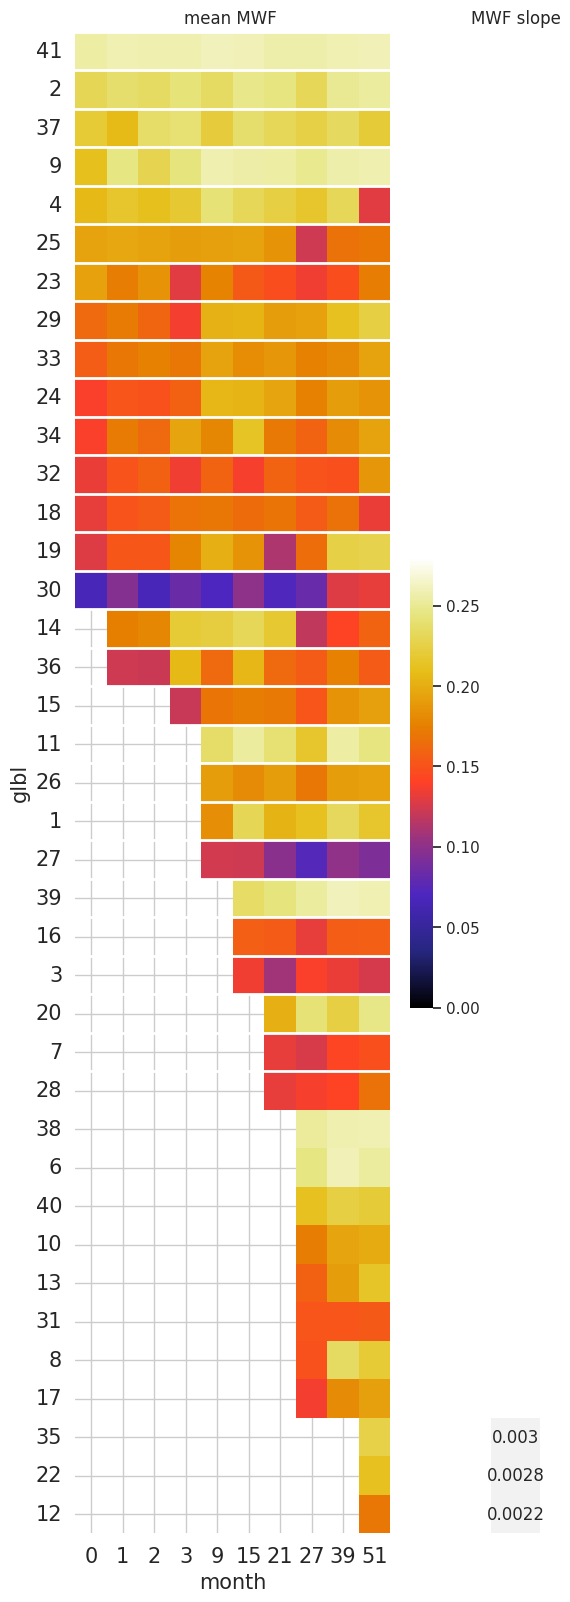

In [35]:
# heatmap for chronic and new lesions
subjects=['DEV027']

for sub in subjects:
    

    #fig, ax=plt.subplots(1,3, sharey=True, gridspec_kw={'width_ratios': [4,4,4]}, figsize=(15, 2*len(afil)/7))
    fig, ax=plt.subplots(1,2, sharey=True, gridspec_kw={'width_ratios': [4,0.5]}, figsize=(6,2*len(afil)/4)) #
    fig.subplots_adjust(wspace=0.1)

    sns.set_style(style='ticks', rc=None)
    # colormap jet MWF values
    
   
    sns.heatmap(afil['median'], ax=ax[0], vmin=0, vmax=0.28 , cbar_kws = dict(shrink= 0.3, use_gridspec=False, location="right"), cmap='CMRmap')
    
    sep=int(((0.013)/0.1)*256)
    cmap = sns.diverging_palette(0, 255, sep=sep, as_cmap=True) 
        
    sns.heatmap(slopesDEV027, ax=ax[1], vmin=-0.1, vmax=0.1, cmap=cmap, annot=True, cbar=None ) #, cbar_kws = dict(shrink= 10,  location="right"),

    for i in range(afil.shape[1]+1):
        ax[0].axhline(i, color='white', lw=2)
        ax[1].axhline(i, color='white', lw=2)
        #ax[2].axhline(i, color='white', lw=2)

    ax[0].set_title('mean MWF ')
    ax[1].set_title('MWF slope')
    #ax[2].set_title('Volume')

    ax[0].set_ylabel('glbl', fontsize=15)
    ax[0].set_xlabel('month', fontsize=15)
    ax[1].set_ylabel('')
    #ax[2].set_ylabel('')
    #ax[2].set_xlabel('')
    ax[0].tick_params(axis='y', which='major', labelsize=15, labelrotation=360)
    ax[0].tick_params(axis='x', which='major', labelsize=15, labelrotation=360)
    ax[1].get_xaxis().set_visible(False)
    ax[1].get_yaxis().set_visible(False)

    sns.set_style(rc = {'axes.facecolor': 'white' })#'#E6E6FA','#F5F5DC'

    print('Example patient Figure 4, subject_id:', sub)
    plt.show()

##DEV 016 

In [36]:
# pivot for DEV016, Figure 5
subjects=['DEV016']

MWFDEV=MWF_slopes[MWF_slopes['subject_id']=='DEV016']
MWFDEV['glbl']=MWFDEV['glbl'].astype('int32')
MWFDEV['slope_late']=MWFDEV['slope_late'].round(3)
afil2=MWFDEV.pivot_table(index=['glbl'], columns='month', values=['median',  'slope_late']) 
by= [('median',0), ('median',1), ('median',2), ('median',3), ('median',9), ('median',15), ('median',21), ('median',27), ('median',39), ('median',51), ('median',63), ('median',75), ('median',87)]
afil2=afil2.sort_values(by=by, ascending=False, na_position='last') #,('mean',1),('mean',3)
#afil2
afil2

/tmp/ipykernel_2024189/4284914811.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MWFDEV['glbl']=MWFDEV['glbl'].astype('int32')
/tmp/ipykernel_2024189/4284914811.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MWFDEV['slope_late']=MWFDEV['slope_late'].round(3)


median                                                              \
month        0         1         2         3         4         5         6    
glbl                                                                          
10     0.251149  0.243718  0.242394  0.224276  0.244905  0.247606  0.247496   
7      0.250139  0.231818  0.255160  0.248273  0.252873  0.227317  0.249837   
5      0.248677  0.252995  0.249045  0.251793  0.237456  0.248577  0.244189   
43     0.220070  0.233344  0.209415  0.214947  0.211885  0.221012  0.217021   
31     0.195403  0.143258  0.122365  0.110165  0.137167  0.105358  0.130378   
25     0.193983  0.171742  0.204898  0.184375  0.194292  0.190845  0.197239   
39     0.193170  0.204038  0.192481  0.206372  0.192834  0.187029  0.180778   
24     0.189606  0.160436  0.182696  0.197256  0.194581  0.160527  0.160303   
17     0.182968  0.168540  0.179773  0.161996  0.182361  0.170047  0.165225   
22     0.168142  0.159525  0.169043  0.156406  0.151713  0.144734  0.140473   
41     0.162208  0.179926  0.172279  0.181718  0.160142  0.177124  0.161122   
30     0.152551  0.161152  0.141501  0.138937  0.145986  0.109386  0.121051   
11     0.152168  0.130061  0.111432  0.108532  0.109052  0.074856  0.119017   
21     0.148195  0.183190  0.165549  0.199802  0.179577  0.197433  0.181351   
34     0.145670  0.159825  0.152685  0.154467  0.146346  0.147118  0.146463   
35     0.134906  0.129981  0.109958  0.115992  0.129967  0.124087  0.155471   
28     0.133136  0.143814  0.148325  0.126055  0.137908  0.096099  0.088376   
9      0.131734  0.138613  0.137175  0.134465  0.143733  0.127450  0.120305   
2      0.129056  0.144930  0.135949  0.126555  0.119371  0.126456  0.148598   
16     0.127278  0.110715  0.112415  0.105577  0.111251  0.130603  0.114309   
18     0.124128  0.098322  0.113078  0.132264  0.129019  0.107076  0.111061   
19     0.122022  0.175030  0.112545  0.151166  0.120482  0.161151  0.134487   
13     0.107169  0.113921  0.095114  0.124158  0.103781  0.097244  0.107772   
12     0.102622  0.109070  0.125341  0.130443  0.140507  0.094618  0.143047   
27     0.100802  0.115070  0.108390  0.117662  0.123934  0.113526  0.104504   
26     0.085179  0.113570  0.070861  0.095351  0.106592  0.123446  0.105957   
29     0.047678  0.089855  0.076909  0.069327  0.069350  0.084787  0.046063   
8           NaN  0.196660  0.210638  0.180935  0.189306  0.224485  0.203271   
3           NaN  0.185497  0.240583  0.218891  0.218841  0.219566  0.216161   
40          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
36          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
37          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
33          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
42          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
32          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
6           NaN       NaN       NaN       NaN       NaN       NaN       NaN   
38          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
4           NaN       NaN       NaN       NaN       NaN       NaN       NaN   
20          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
45          NaN       NaN       NaN       NaN       NaN       NaN       NaN   

                                     ...                     slope_late  \
month        9         15        21  ...        75        87         1    
glbl                                 ...                                  
10     0.210056  0.185543  0.232532  ...  0.238958  0.222721        NaN   
7      0.235273  0.258493  0.249616  ...  0.259625  0.253724        NaN   
5      0.258254  0.255148  0.253031  ...  0.243110  0.246522        NaN   
43     0.193093  0.177158  0.199601  ...  0.206853  0.220937        NaN   
31     0.072709  0.102033  0.146411  ...  0.163391  0.155721        NaN   
25     0.17

In [37]:
# select the slopes for DEV016, Figure 5
slopesDEV016= afil2[('slope_late', 27)]
slopesDEV016=slopesDEV016.to_frame()

subject_id: DEV016


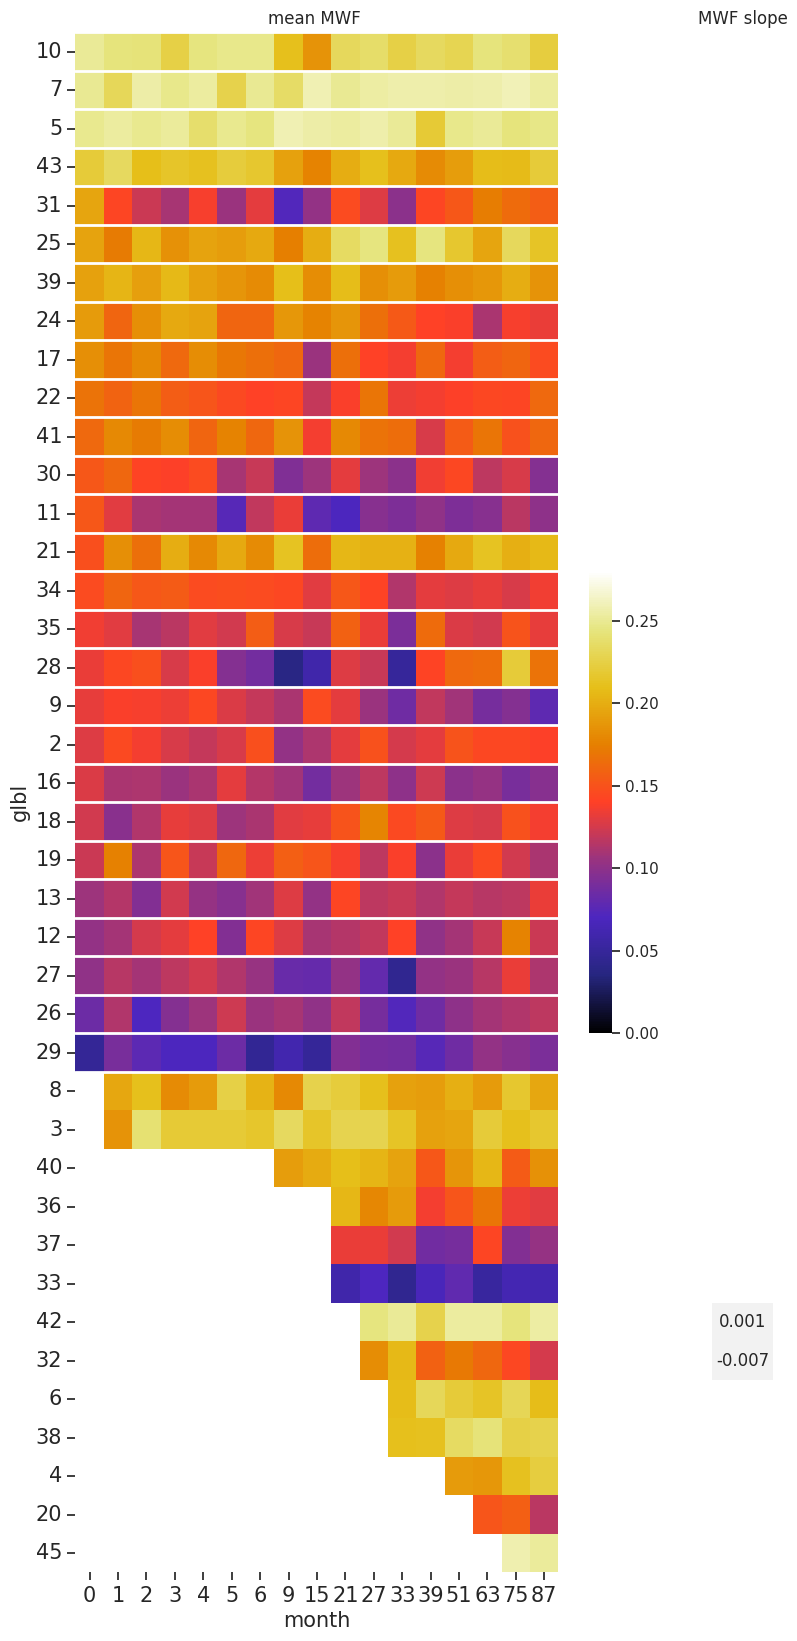

In [38]:
# Heatmap Figure 5
subjects=['DEV016']

for sub in subjects:
    fig, ax=plt.subplots(1,2, sharey=True, gridspec_kw={'width_ratios': [5,0.5]}, figsize=(9,2*len(afil2)/4)) #
    fig.subplots_adjust(wspace=0.1)

    sns.set_style(style='ticks', rc=None)
    # colormap jet MWF values
    
    sns.heatmap(afil2['median'], ax=ax[0], vmin=0, vmax=0.28 , cbar_kws = dict(shrink= 0.3, use_gridspec=False, location="right"), cmap='CMRmap')
    
    sep=int(((0.013)/0.1)*256)
    cmap = sns.diverging_palette(0, 255, sep=sep, as_cmap=True) 
        
    sns.heatmap(slopesDEV016, ax=ax[1], vmin=-0.1, vmax=0.1, cmap=cmap, annot=True, cbar=None ) #, cbar_kws = dict(shrink= 10,  location="right"),

    for i in range(afil.shape[1]+1):
        ax[0].axhline(i, color='white', lw=2)
        ax[1].axhline(i, color='white', lw=2)
        #ax[2].axhline(i, color='white', lw=2)

    ax[0].set_title('mean MWF ')
    ax[1].set_title('MWF slope')
    #ax[2].set_title('Volume')

    ax[0].set_ylabel('glbl', fontsize=15)
    ax[0].set_xlabel('month', fontsize=15)
    ax[1].set_ylabel('')
    #ax[2].set_ylabel('')
    #ax[2].set_xlabel('')
    ax[0].tick_params(axis='y', which='major', labelsize=15, labelrotation=360)
    ax[0].tick_params(axis='x', which='major', labelsize=15, labelrotation=360)
    ax[1].get_xaxis().set_visible(False)
    ax[1].get_yaxis().set_visible(False)

    sns.set_style(rc = {'axes.facecolor': 'white' })#'#E6E6FA','#F5F5DC'

    print('subject_id:', sub)
    plt.show()

## Figure_6_Inter_Patient_Comparison

In [39]:
# load data from LMM result IN WHICH SLOPES WERE CLASSIFIED IN INCREASING DECREASING OR STABLE
path= join(projectdir,'derivatives','paper_results','percent_rising_falling.txt')
df_rising_falling=pd.read_csv(path, sep ='\t')

In [40]:
df_rising_falling['late_stable']=100-df_rising_falling['late_falling']-df_rising_falling['late_rising']
df_rising_falling=df_rising_falling.query('subject_id!= "DEV001"')

Figure 6 , Inter-patient comparison of MWF slope development

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 
data = df_rising_falling
data['late_falling_neg'] = data['late_falling']*-1 
data['late_stable_neg'] = data['late_stable']*-1 
data['late_combi']= data['late_stable_neg']+ data['late_falling_neg']
data= df_rising_falling.sort_values(by=['late_combi', 'late_falling_neg'], ascending=False)
# define y position for subjects
y_labels = data['subject_id']
y_pos = np.arange(len(y_labels))

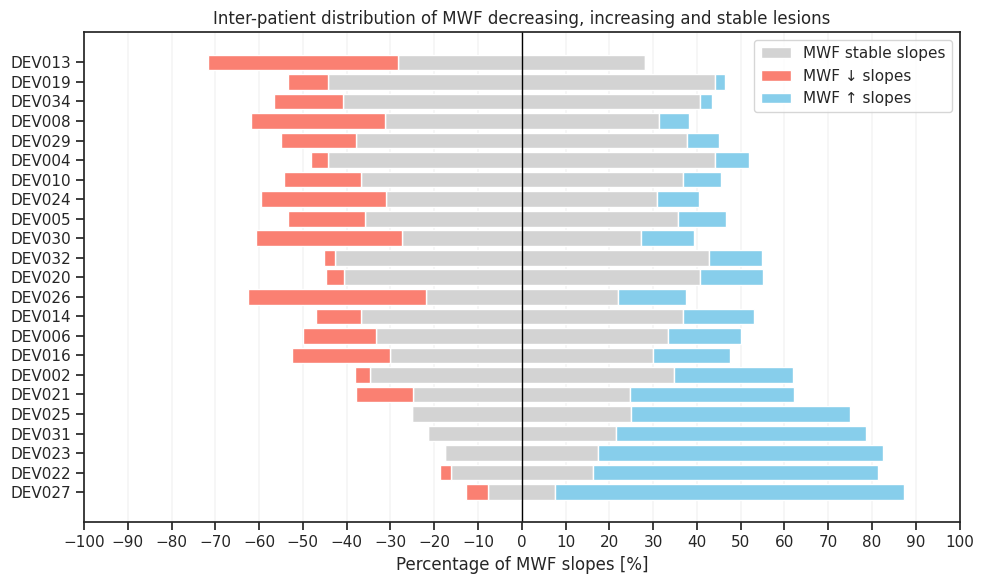

In [42]:
#data = df_rising_falling
data['late_falling_neg'] = data['late_falling']*-1 
stable_width = data['late_stable'].abs()  # total width
stable_left = -stable_width / 2
bar_values_neg = data['late_falling_neg']  # already negative
bar_values_pos = data['late_rising']

fig, ax = plt.subplots(figsize=(10, 6))

# stable centered at 0
ax.barh(
    y_pos,
    stable_width,
    left=stable_left,
    color='lightgrey',
    label='MWF stable slopes'
)

# falling: extend left from stable
ax.barh(
    y_pos,
    bar_values_neg,
    left=stable_left,
    color='salmon',
    label='MWF ↓ slopes'
)

# increasing: extend right from stable
ax.barh(
    y_pos,
    bar_values_pos,
    left=stable_width / 2,
    color='skyblue',
    label='MWF ↑ slopes'
)
# Achsen und Layout
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_xlabel('Percentage of MWF slopes [%]')
ax.set_title('Inter-patient distribution of MWF decreasing, increasing and stable lesions')
ax.axvline(0, color='black', linewidth=1)
ax.legend()
ax.xaxis.set_ticks(np.arange(-100, 110, 10))
plt.grid(axis="x", linewidth=0.25)
plt.tight_layout()
plt.show()

In [43]:
# Percentage and number of relative slope distribution 
df_rising_falling= df_rising_falling.copy()
df_rising_falling['combi']= df_rising_falling['late_stable']+df_rising_falling['late_falling']
df_rising_falling.sort_values(by=['combi'], inplace=True, ascending=False)
df_rising_falling['patient_id_nr']= pd.factorize(df_rising_falling['subject_id']) [0] + 1
df_rising_falling['patient_id']= 'Patient '

df_rising_falling['patient_id']= df_rising_falling['patient_id']+ df_rising_falling['patient_id_nr'].astype(str)
df_rising_falling= df_rising_falling.query('subject_id != "DEV001"')
#df_rising_falling
##df_rising_falling['remy_win']= []
##slopes_df.loc[(slopes_df['slope'] > 0.01/12) , 'category'] = 'increase' 
df_rising_falling.loc[(df_rising_falling['late_rising']>50),'remy_win']= 1
df_rising_falling.loc[(df_rising_falling['late_rising']<=50),'remy_win']= 0
df_rising_falling.loc[(df_rising_falling['late_falling']>50),'remy_loser']= 1
df_rising_falling.loc[(df_rising_falling['late_falling']<=50),'remy_loser']= 0
df_rising_falling.loc[(df_rising_falling['late_stable']>50),'remy_stable']= 1
df_rising_falling.loc[(df_rising_falling['late_stable']<=50),'remy_stable']= 0
#df_rising_falling['remy_win'].astype('int')
df_rising_falling
rise=round(len(df_rising_falling.query('remy_win==1'))/23*100,0)
stable= round(len(df_rising_falling.query('remy_stable==1'))/23*100, 0)
lose= round(len(df_rising_falling.query('remy_loser==1'))/23*100, 0)
print('proportion of Patients of late rising >50% ,', rise,'%',',number of patients predominantly rising', round(rise*23/100,0) )
print('proportion of Patients of late stable >50% ,', stable,'%',',number of patients predominantly stable', round(stable*23/100,0) )
print('proportion of Patients of late loser >50% ,',  lose, '%',',number of patients predominantly falling', round(lose*23/100,0))
print('proportion of Patients without any predominance >=50% ,', round(100-(rise+stable+lose),0),'%', ',number of patients no predominance', round(round(100-(rise+stable+lose),0)*23/100,0))
df_rising_falling['no_predominance']= (df_rising_falling['remy_win']+df_rising_falling['remy_stable']+ df_rising_falling['remy_loser']-1)*-1

proportion of Patients of late rising >50% , 17.0 % ,number of patients predominantly rising 4.0
proportion of Patients of late stable >50% , 70.0 % ,number of patients predominantly stable 16.0
proportion of Patients of late loser >50% , 0.0 % ,number of patients predominantly falling 0.0
proportion of Patients without any predominance >=50% , 13.0 % ,number of patients no predominance 3.0


## Correlation Analysis EDSS progression

In [44]:
last_EDSS= clinical_df.groupby('subject_id')['EDSS'].last()
m15_EDSS= clinical_df.query('month==15')#['EDSS']
m15_EDSS= m15_EDSS.groupby('subject_id')['EDSS'].last()
#clinical_df['EDSS15m']=
#result['diff_snfl']= result.groupby('mpi')['finalval'].diff().abs()
last_EDSS=last_EDSS.to_frame().reset_index()
m15_EDSS=m15_EDSS.to_frame().reset_index()

In [45]:
last_EDSS.rename(columns={'EDSS': 'EDSS_end'}, inplace=True)
m15_EDSS.rename(columns={'EDSS': 'EDSS_15m'}, inplace=True)

In [46]:
EDSS_merge_df= pd.merge(left=m15_EDSS, how='left', right= last_EDSS, left_on=['subject_id'], right_on=['subject_id'])
#EDSS_merge_df['EDSS_change']= EDSS_y-EDSS_x
EDSS_merge_df['EDSS_change']=EDSS_merge_df['EDSS_end']-EDSS_merge_df['EDSS_15m']
EDSS_merge_df.sort_values(by="subject_id")
EDSS_change=EDSS_merge_df['EDSS_change'].to_list()
EDSS_merge_df

,subject_id,EDSS_15m,EDSS_end,EDSS_change
0,DEV002,1.5,1.5,0.0
1,DEV004,2.0,3.5,1.5
2,DEV005,2.0,1.5,-0.5
3,DEV006,2.0,1.5,-0.5
4,DEV008,2.0,3.0,1.0
5,DEV010,3.5,2.5,-1.0
6,DEV013,2.0,2.0,0.0
7,DEV014,3.0,3.0,0.0
8,DEV016,4.0,6.0,2.0
9,DEV019,1.5,1.0,-0.5


## patient_characteristics

In [47]:
#3.1 Patient characteristics 
mean_age=demography_df.query('subject_id !=["DEV003","DEV007","DEV009","DEV012","DEV018"]')['age_baseline'].mean()
sd_age=demography_df.query('subject_id !=["DEV003","DEV007","DEV009","DEV012","DEV018"]')['age_baseline'].std()
print('mean age at baseline y ', round(mean_age,1))
print('sd age at baseline y ', round(sd_age,1))

females =len(demography_df.query('subject_id !=["DEV003","DEV007","DEV009","DEV012","DEV018"] and gender=="F"'))
male =len(demography_df.query('subject_id !=["DEV003","DEV007","DEV009","DEV012","DEV018"] and gender=="M"'))
print('number of females in cohort  ', females)
print('number of males in cohort  ', male)

mean age at baseline y  33.1
sd age at baseline y  8.9
number of females in cohort   21
number of males in cohort   3


In [48]:
mean_DoD_baseline= clinical_df.query('month == 0')['disease_duration_yrs'].mean()
sd_DoD_baseline= clinical_df.query('month == 0')['disease_duration_yrs'].std()
print('mean Duration of Disease baseline y ', round(mean_DoD_baseline,1))
print('sd Duration of Disease baseline y ', round(sd_DoD_baseline,1))

mean_EDSS_baseline= clinical_df.query('month == 0')['EDSS'].mean()
sd_EDSS_baseline= clinical_df.query('month == 0')['EDSS'].std()
print('mean EDSS baseline ',round(mean_EDSS_baseline,1))
print('sd EDSS ', round(sd_EDSS_baseline,1))

mean_study_duration= clinical_df.groupby('subject_id')['month'].last().mean()
std_study_duration= clinical_df.groupby('subject_id')['month'].last().std()
print('mean study duration in years ', round(mean_study_duration/12,1))
print('sd study duration in years ', round(std_study_duration/12),1)

relapse_patient= clinical_df.query('relapse==1')
mean_relapse_per_patient= relapse_patient.groupby('subject_id')['relapse'].count()
#std_relapse_per_patient= clinical_df.groupby('subject_id')['relapse'].std()
print('patients with relapses ', mean_relapse_per_patient,'nr_pat_with_relapses', len(mean_relapse_per_patient))


mean Duration of Disease baseline y  4.7
sd Duration of Disease baseline y  6.0
mean EDSS baseline  2.3
sd EDSS  0.8
mean study duration in years  5.6
sd study duration in years  2 1
patients with relapses  subject_id
DEV001    1
DEV002    3
DEV006    1
DEV008    1
DEV016    3
DEV021    1
DEV025    1
DEV027    2
DEV030    1
Name: relapse, dtype: int64 nr_pat_with_relapses 9


In [49]:
mean_age_controls= demographic_controls.query('match_longterm==1')['age'].mean()
std_age_controls= demographic_controls.query('match_longterm==1')['age'].std()
print('mean age controls at baseline y ', round(mean_age_controls,1))
print('sd age at controls baseline y ', round(std_age_controls,1))

females =len(demographic_controls.query('match_longterm==1 and sex=="F"'))
male =len(demographic_controls.query('match_longterm==1 and sex=="M"'))
print('number of females in cohort  ', females)
print('number of males in cohort  ', male)

mean age controls at baseline y  34.2
sd age at controls baseline y  10.2
number of females in cohort   16
number of males in cohort   8
